# Tech Challenge - Classificação da Qualidade de Vinhos

Este notebook apresenta uma análise simples da base **WineQT** e treina modelos de classificação para prever se um vinho pode ser considerado de alta qualidade.

A variável original `quality` foi transformada em uma classificação binária:

- **Alta qualidade:** `quality >= 7`
- **Baixa ou média qualidade:** `quality < 7`

## 1. Importação das Bibliotecas e Leitura dos Dados

Nesta etapa, são importadas as bibliotecas utilizadas no projeto e a base de dados é carregada a partir da pasta `data`.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

sns.set(style='whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'

DATA_PATH = Path('../data/WineQT.csv')
RESULTS_PATH = Path('../results')

if not DATA_PATH.exists():
    DATA_PATH = Path('data/WineQT.csv')
    RESULTS_PATH = Path('results')

RESULTS_PATH.mkdir(exist_ok=True)
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
linhas_antes = len(df)

# A coluna Id é apenas um identificador, então é excluída da checagem de duplicatas
df = df.drop_duplicates(subset=df.columns.drop('Id')).reset_index(drop=True)
linhas_removidas = linhas_antes - len(df)

print('Linhas antes da remoção de duplicatas:', linhas_antes)
print('Duplicatas removidas:', linhas_removidas)
print('Linhas após a limpeza:', len(df))

df.head()


Linhas antes da remoção de duplicatas: 1143
Duplicatas removidas: 125
Linhas após a limpeza: 1018


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5


## 2. Compreensão do Problema

O objetivo do projeto é utilizar características físico-químicas dos vinhos para prever se uma amostra pertence ou não ao grupo de alta qualidade.

Para simplificar o problema, a nota original foi convertida em uma variável binária chamada `quality_binary`. Nessa nova variável, o valor `1` representa vinhos com nota maior ou igual a 7, enquanto o valor `0` representa vinhos com nota menor que 7.

Antes da análise, também foi feita a remoção de duplicatas. Como a coluna `Id` é apenas um identificador, ela não foi usada para decidir se duas linhas eram duplicadas.


In [33]:
df['quality_binary'] = (df['quality'] >= 7).astype(int)

print('Dimensão da base:', df.shape)
print('\nValores faltantes por coluna:')
print(df.isnull().sum())
print('\nDistribuição da qualidade original:')
print(df['quality'].value_counts().sort_index())
print('\nDistribuição da classificação binária:')
print(df['quality_binary'].value_counts())

Dimensão da base: (1018, 14)

Valores faltantes por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
quality_binary          0
dtype: int64

Distribuição da qualidade original:
quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64

Distribuição da classificação binária:
quality_binary
0    881
1    137
Name: count, dtype: int64


Total de vinhos analisados: 1018
Vinhos de alta qualidade: 137 (13.46%)
Vinhos de baixa ou média qualidade: 881 (86.54%)


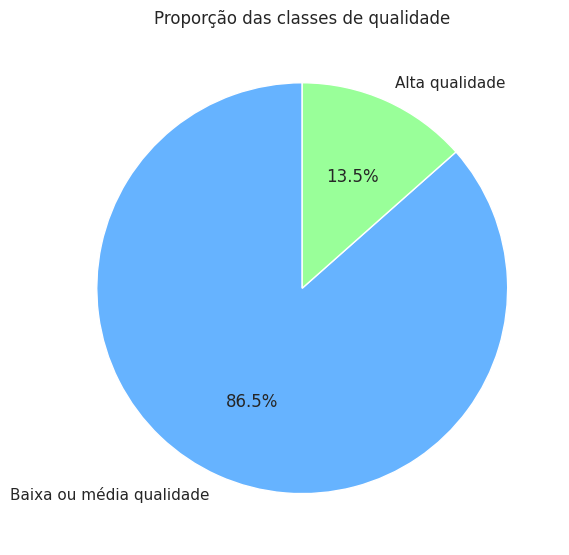

In [34]:
total_vinhos = len(df)
vinhos_alta_qualidade = df['quality_binary'].sum()
vinhos_baixa_media_qualidade = total_vinhos - vinhos_alta_qualidade

percentual_alta = vinhos_alta_qualidade / total_vinhos * 100
percentual_baixa_media = vinhos_baixa_media_qualidade / total_vinhos * 100

print(f'Total de vinhos analisados: {total_vinhos}')
print(f'Vinhos de alta qualidade: {vinhos_alta_qualidade} ({percentual_alta:.2f}%)')
print(f'Vinhos de baixa ou média qualidade: {vinhos_baixa_media_qualidade} ({percentual_baixa_media:.2f}%)')

valores = [vinhos_baixa_media_qualidade, vinhos_alta_qualidade]
rotulos = ['Baixa ou média qualidade', 'Alta qualidade']
cores = ['#66b3ff', '#99ff99']

plt.figure(figsize=(6, 6))
plt.pie(
    valores,
    labels=rotulos,
    autopct='%1.1f%%',
    startangle=90,
    colors=cores
)
plt.title('Proporção das classes de qualidade')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'pizza_classes_qualidade.png', dpi=120)
plt.show()

## 3. Análise Exploratória dos Dados

A análise exploratória ajuda a entender o comportamento da base antes da modelagem. Foram observadas as estatísticas descritivas, a distribuição das notas, o balanceamento das classes e as correlações entre as variáveis.


In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1018.0,8.288507,1.741324,4.60000,7.100000,7.900000,9.100000,15.90000
volatile acidity,1018.0,0.533541,0.183167,0.12000,0.390000,0.520000,0.645000,1.58000
citric acid,1018.0,0.268802,0.196229,0.00000,0.090000,0.250000,0.420000,1.00000
residual sugar,1018.0,2.524411,1.314850,0.90000,1.900000,2.200000,2.600000,15.50000
chlorides,1018.0,0.087187,0.048506,0.01200,0.070000,0.079000,0.090000,0.61100
free sulfur dioxide,1018.0,15.648821,10.176525,1.00000,7.000000,13.000000,21.000000,68.00000
total sulfur dioxide,1018.0,46.325639,33.123533,6.00000,21.000000,38.000000,62.000000,289.00000
density,1018.0,0.996700,0.001916,0.99007,0.995572,0.996665,0.997827,1.00369
pH,1018.0,3.311503,0.157775,2.74000,3.210000,3.310000,3.400000,4.01000
sulphates,1018.0,0.656817,0.167542,0.33000,0.550000,0.620000,0.720000,2.00000


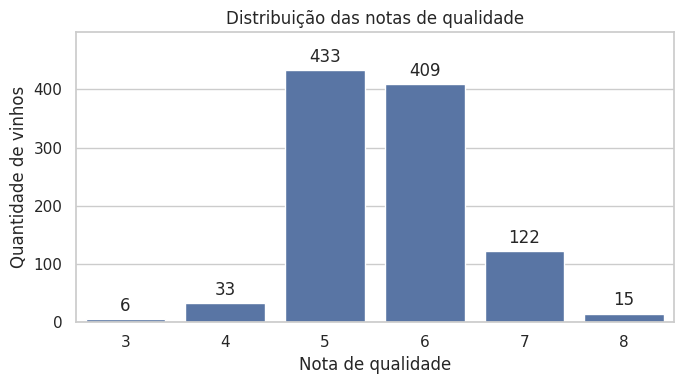

In [36]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='quality')
plt.title('Distribuição das notas de qualidade')
plt.xlabel('Nota de qualidade')
plt.ylabel('Quantidade de vinhos')

for barra in ax.containers:
    ax.bar_label(barra, fmt='%d', padding=3)

maior_barra = max([patch.get_height() for patch in ax.patches])
ax.set_ylim(0, maior_barra * 1.15)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'distribuicao_qualidade.png', dpi=120)
plt.show()

Pela distribuição das notas, é possível perceber que a maior parte dos vinhos está concentrada nas notas intermediárias, principalmente entre 5 e 6. Vinhos com notas 7 ou 8 aparecem em menor quantidade.

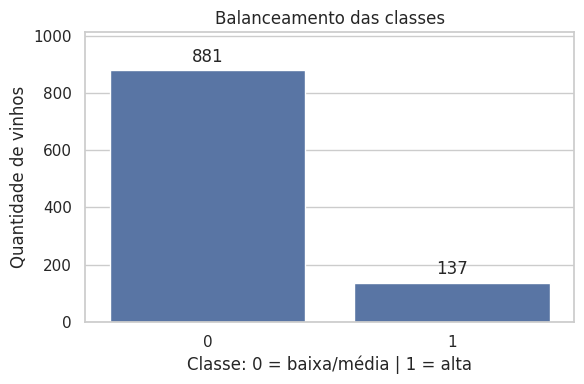

In [37]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='quality_binary')
plt.title('Balanceamento das classes')
plt.xlabel('Classe: 0 = baixa/m\u00e9dia | 1 = alta')
plt.ylabel('Quantidade de vinhos')

for barra in ax.containers:
    ax.bar_label(barra, fmt='%d', padding=3)

maior_barra = max([patch.get_height() for patch in ax.patches])
ax.set_ylim(0, maior_barra * 1.15)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'balanceamento_classes.png', dpi=120)
plt.show()

A classe de alta qualidade é menor do que a classe de baixa ou média qualidade. Esse desbalanceamento precisa ser considerado na avaliação dos modelos, pois a acurácia sozinha pode passar uma impressão exageradamente positiva.

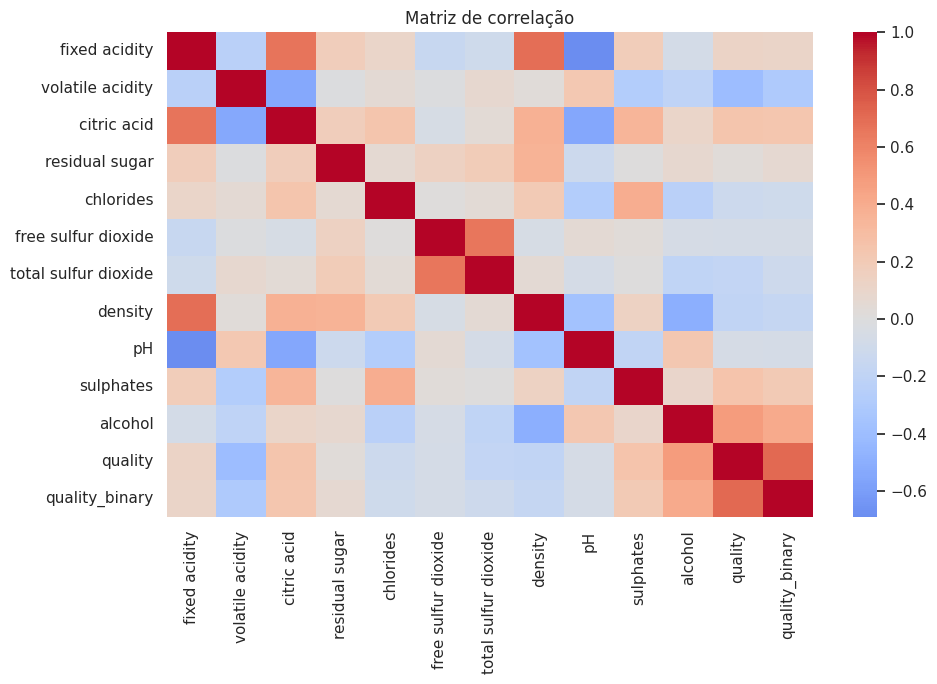

quality_binary          1.000000
quality                 0.713515
alcohol                 0.410331
citric acid             0.237369
sulphates               0.213071
fixed acidity           0.107952
residual sugar          0.064405
pH                     -0.065270
free sulfur dioxide    -0.067319
chlorides              -0.105595
total sulfur dioxide   -0.114990
density                -0.166497
volatile acidity       -0.302343
Name: quality_binary, dtype: float64

In [38]:
corr = df.drop(columns=['Id']).corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de correlação')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'matriz_correlacao.png', dpi=120)
plt.show()

corr['quality_binary'].sort_values(ascending=False)

**Interpretação das correlações:** variáveis com correlação positiva tendem a aumentar junto com a classificação de alta qualidade. Já variáveis com correlação negativa tendem a se comportar de forma inversa. Em geral, o teor alcoólico costuma aparecer como uma das variáveis mais associadas a vinhos de melhor avaliação, enquanto a acidez volátil costuma apresentar relação negativa.

## 3.1 Distribuição das Variáveis e Detecção de Outliers

Além da distribuição da nota de qualidade, também é importante observar como cada variável físico-química se distribui e se existem valores muito distantes do padrão (outliers), que podem indicar erros de medição ou vinhos com composição naturalmente atípica.

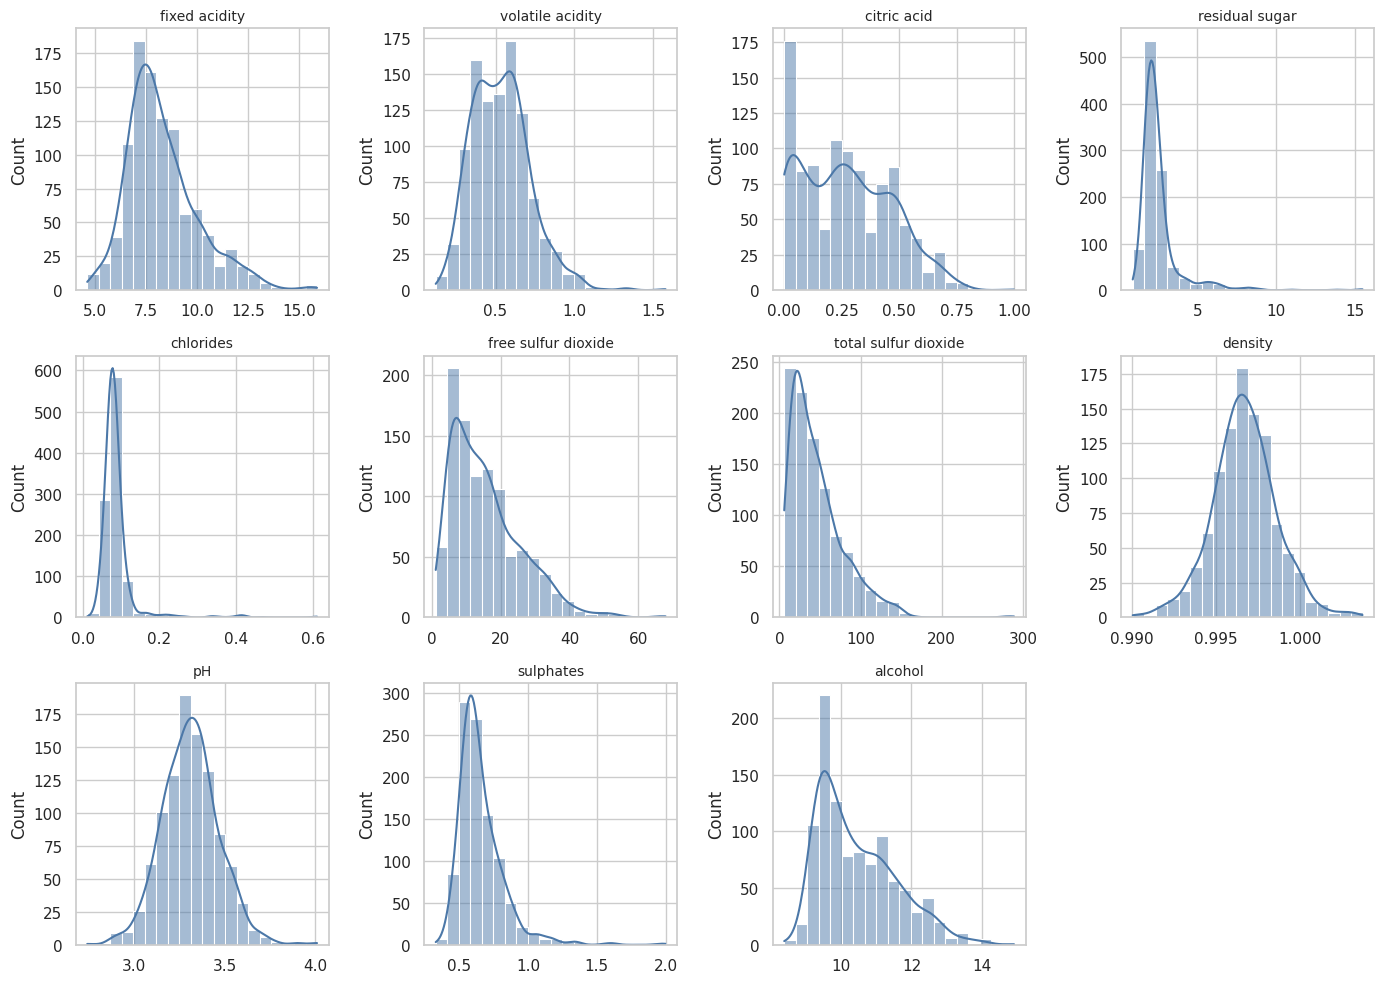

In [39]:
colunas_numericas = [col for col in df.columns if col not in ['quality', 'quality_binary', 'Id']]

plt.figure(figsize=(14, 10))
for i, col in enumerate(colunas_numericas):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[col], kde=True, bins=20, color='#4c78a8')
    plt.title(col, fontsize=10)
    plt.xlabel('')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'distribuicao_variaveis.png', dpi=120)
plt.show()


A maioria das variáveis apresenta distribuição próxima da normal, com algumas assimetrias (como `residual sugar` e `chlorides`, que possuem cauda mais longa à direita). Essa assimetria já é um indício de que pode haver valores extremos, investigados a seguir com boxplots.

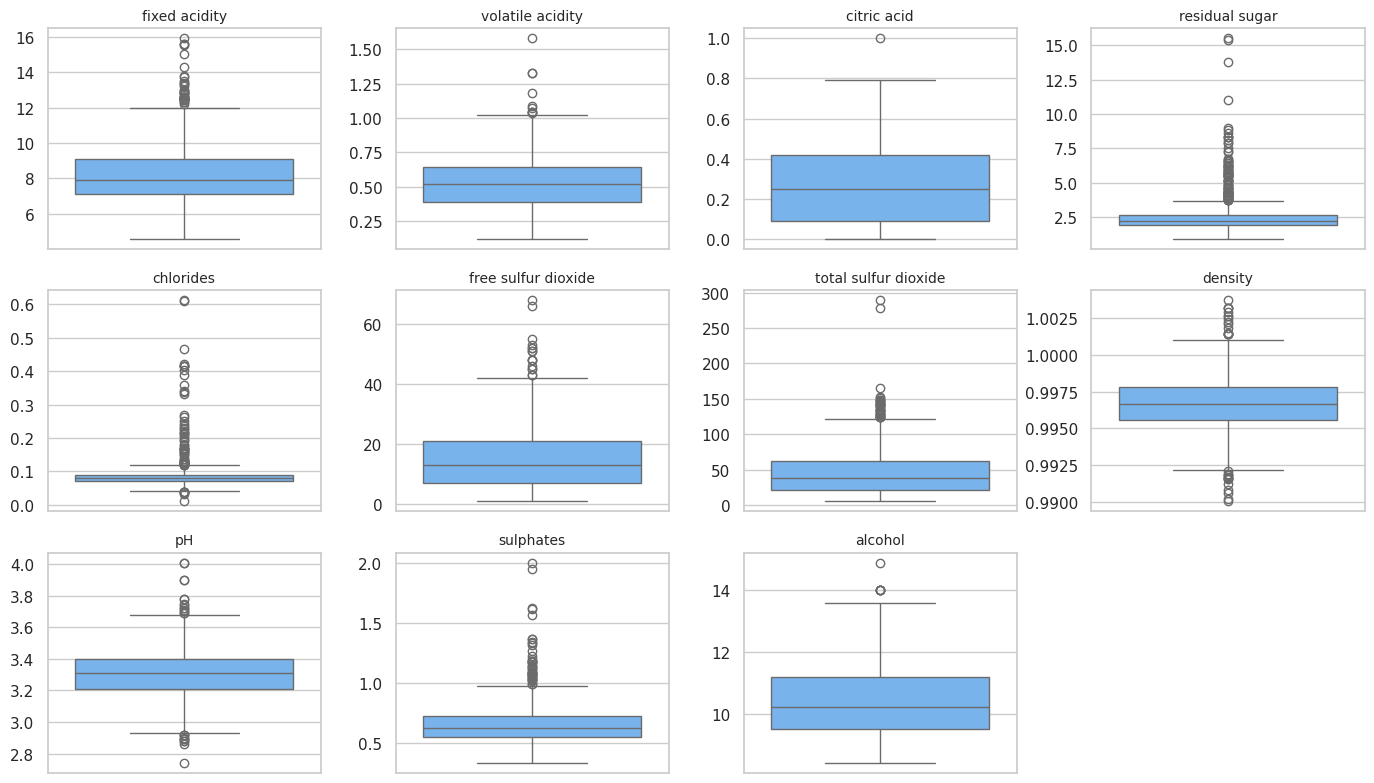

In [40]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(colunas_numericas):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(y=df[col], color='#66b3ff')
    plt.title(col, fontsize=10)
    plt.ylabel('')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'boxplots_outliers.png', dpi=120)
plt.show()


In [41]:
outliers_resumo = {}

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)].shape[0]
    outliers_resumo[col] = n_outliers

outliers_df = pd.Series(outliers_resumo, name='qtd_outliers').sort_values(ascending=False)
outliers_percentual = (outliers_df / len(df) * 100).round(2)

pd.DataFrame({'qtd_outliers': outliers_df, 'percentual': outliers_percentual})


,qtd_outliers,percentual
residual sugar,95,9.33
chlorides,71,6.97
sulphates,41,4.03
fixed acidity,37,3.63
total sulfur dioxide,33,3.24
density,30,2.95
pH,24,2.36
free sulfur dioxide,16,1.57
volatile acidity,10,0.98
alcohol,6,0.59


**Interpretação e decisão sobre os outliers:** algumas variáveis (como `residual sugar`, `chlorides` e `sulphates`) apresentam uma quantidade maior de valores fora do intervalo interquartil (IQR). No entanto, esses valores não foram removidos da base, por dois motivos principais:

1. Em dados físico-químicos de vinhos, esses valores extremos costumam representar vinhos com composição naturalmente diferente (mais doces, mais ácidos, etc.), e não necessariamente erros de medição.
2. O Random Forest é um modelo robusto a outliers por natureza, e a Regressão Logística já foi treinada com os dados padronizados (`StandardScaler`), o que reduz o impacto de valores extremos no treinamento.

Por esses motivos, optou-se por manter todos os registros na base, preservando a variabilidade real dos vinhos analisados.

## 4. Pré-processamento

Não foram encontrados valores faltantes na base. A coluna `Id` foi removida da modelagem por ser apenas um identificador.

A separação dos dados foi feita com **75% para treino** e **25% para teste**, sempre usando o mesmo `random_state = 42`. A separação também foi estratificada, para manter uma proporção parecida entre vinhos de alta qualidade e baixa/média qualidade no treino e no teste.


**Sobre feature engineering:** foi avaliada a criação de novas variáveis derivadas (por exemplo, a razão entre `free sulfur dioxide` e `total sulfur dioxide`). Optou-se por não incluir novas features no modelo final, pois as 11 variáveis físico-químicas originais já capturam as informações relevantes para a classificação, e a matriz de correlação não indicou lacunas que justificassem a criação de variáveis compostas. Essa decisão prioriza a interpretabilidade do modelo, especialmente da Regressão Logística.

In [42]:
features = [col for col in df.columns if col not in ['quality', 'quality_binary', 'Id']]

X = df[features]
y = df['quality_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Base de treino:', X_train.shape)
print('Base de teste:', X_test.shape)
print('\nDistribuição no treino:')
print(y_train.value_counts().sort_index())
print('\nDistribuição no teste:')
print(y_test.value_counts().sort_index())


Base de treino: (763, 11)
Base de teste: (255, 11)

Distribuição no treino:
quality_binary
0    660
1    103
Name: count, dtype: int64

Distribuição no teste:
quality_binary
0    221
1     34
Name: count, dtype: int64


## 5. Modelos sem Balanceamento

Primeiro, os modelos foram treinados sem nenhum ajuste de balanceamento. Isso serve como comparação inicial para entender como eles se comportam com a base original, que tem muito mais vinhos de baixa/média qualidade do que vinhos de alta qualidade.


In [43]:
metricas_modelos = []


### 5.1 Logistic Regression

A Regressão Logística foi usada como modelo de comparação inicial. Ela é mais simples e ajuda a entender o comportamento geral das variáveis.


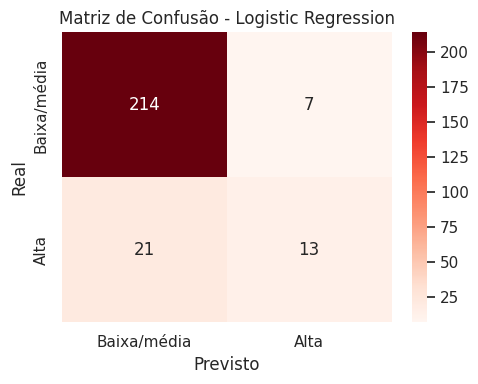

Relatório resumido - Logistic Regression


,modelo,balanceamento,acurácia,precisão,recall,f1_score,roc_auc
0,Logistic Regression,Sem balanceamento,0.890196,0.65,0.382353,0.481481,0.899787



Relatório por classe:
              precision    recall  f1-score   support

 Baixa/média       0.91      0.97      0.94       221
        Alta       0.65      0.38      0.48        34

    accuracy                           0.89       255
   macro avg       0.78      0.68      0.71       255
weighted avg       0.88      0.89      0.88       255



In [44]:
logistic_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

logistic_regression.fit(X_train, y_train)

y_pred_lr = logistic_regression.predict(X_test)
y_proba_lr = logistic_regression.predict_proba(X_test)[:, 1]

metricas_lr = {
    'modelo': 'Logistic Regression',
    'balanceamento': 'Sem balanceamento',
    'acurácia': accuracy_score(y_test, y_pred_lr),
    'precisão': precision_score(y_test, y_pred_lr, zero_division=0),
    'recall': recall_score(y_test, y_pred_lr, zero_division=0),
    'f1_score': f1_score(y_test, y_pred_lr, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_lr)
}
metricas_modelos.append(metricas_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Baixa/média', 'Alta'],
    yticklabels=['Baixa/média', 'Alta']
)
plt.title('Matriz de Confusão - Logistic Regression')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'matriz_confusao_logistic_regression.png', dpi=120)
plt.show()

print('Relatório resumido - Logistic Regression')
display(pd.DataFrame([metricas_lr]))

print('\nRelatório por classe:')
print(classification_report(y_test, y_pred_lr, target_names=['Baixa/média', 'Alta'], zero_division=0))


### 5.2 Random Forest

O Random Forest foi usado como segundo modelo porque trabalha com várias árvores de decisão e consegue capturar relações mais complexas entre as variáveis. Mesmo assim, ele não é obrigado a ser melhor em todos os testes, principalmente quando a base é desbalanceada e a classe de alta qualidade tem poucos exemplos.


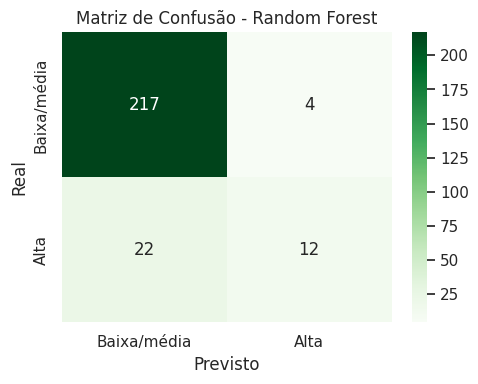

Relatório resumido - Random Forest


,modelo,balanceamento,acurácia,precisão,recall,f1_score,roc_auc
0,Random Forest,Sem balanceamento,0.898039,0.75,0.352941,0.48,0.909502



Relatório por classe:
              precision    recall  f1-score   support

 Baixa/média       0.91      0.98      0.94       221
        Alta       0.75      0.35      0.48        34

    accuracy                           0.90       255
   macro avg       0.83      0.67      0.71       255
weighted avg       0.89      0.90      0.88       255



In [45]:
random_forest = RandomForestClassifier(
    n_estimators=150,
    random_state=RANDOM_STATE
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_proba_rf = random_forest.predict_proba(X_test)[:, 1]

metricas_rf = {
    'modelo': 'Random Forest',
    'balanceamento': 'Sem balanceamento',
    'acurácia': accuracy_score(y_test, y_pred_rf),
    'precisão': precision_score(y_test, y_pred_rf, zero_division=0),
    'recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'f1_score': f1_score(y_test, y_pred_rf, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_rf)
}
metricas_modelos.append(metricas_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Baixa/média', 'Alta'],
    yticklabels=['Baixa/média', 'Alta']
)
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'matriz_confusao_random_forest.png', dpi=120)
plt.show()

print('Relatório resumido - Random Forest')
display(pd.DataFrame([metricas_rf]))

print('\nRelatório por classe:')
print(classification_report(y_test, y_pred_rf, target_names=['Baixa/média', 'Alta'], zero_division=0))


### 5.3 Comparação Inicial

A comparação inicial mostra que a acurácia pode ficar alta mesmo quando o modelo tem dificuldade para encontrar os vinhos de alta qualidade. Por isso, além da acurácia, também foram analisados precisão, recall, F1-score e ROC-AUC.


In [46]:
comparacao_inicial = pd.DataFrame(metricas_modelos)
comparacao_inicial


,modelo,balanceamento,acurácia,precisão,recall,f1_score,roc_auc
0,Logistic Regression,Sem balanceamento,0.890196,0.65,0.382353,0.481481,0.899787
1,Random Forest,Sem balanceamento,0.898039,0.75,0.352941,0.480000,0.909502


## 6. Balanceamento das Amostras

A base tem bem menos vinhos de alta qualidade do que vinhos de baixa/média qualidade. Esse desbalanceamento é importante porque o modelo pode aprender a favorecer a classe maior.

Para tratar isso de forma simples, os dois modelos foram treinados novamente usando `class_weight='balanced'`. Esse parâmetro dá mais peso para a classe menor durante o treinamento, sem precisar criar dados artificiais.


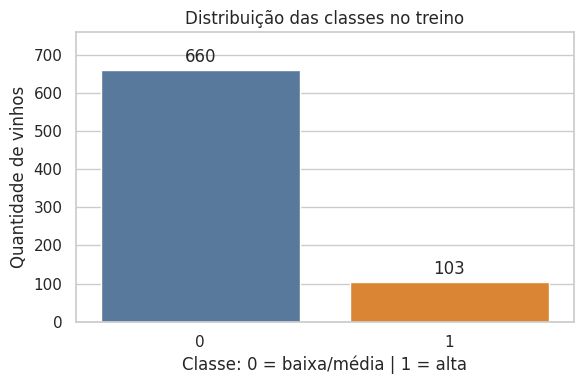

In [47]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_train, hue=y_train, palette=['#4c78a8', '#f58518'], legend=False)
plt.title('Distribuição das classes no treino')
plt.xlabel('Classe: 0 = baixa/média | 1 = alta')
plt.ylabel('Quantidade de vinhos')

for barra in ax.containers:
    ax.bar_label(barra, fmt='%d', padding=3)

maior_barra = max([patch.get_height() for patch in ax.patches])
ax.set_ylim(0, maior_barra * 1.15)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'balanceamento_treino.png', dpi=120)
plt.show()


### 6.1 Logistic Regression com Balanceamento

Agora a Regressão Logística foi treinada novamente, mas considerando o peso maior da classe de alta qualidade.


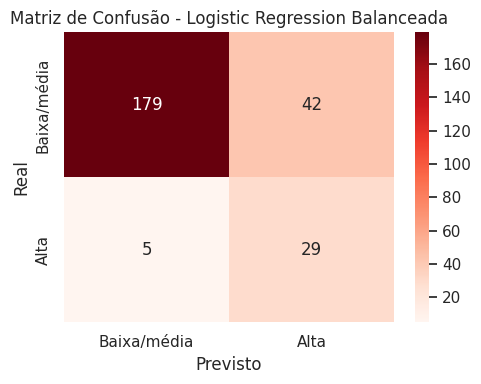

Relatório resumido - Logistic Regression balanceada


,modelo,balanceamento,acurácia,precisão,recall,f1_score,roc_auc
0,Logistic Regression,Com balanceamento,0.815686,0.408451,0.852941,0.552381,0.895795



Relatório por classe:
              precision    recall  f1-score   support

 Baixa/média       0.97      0.81      0.88       221
        Alta       0.41      0.85      0.55        34

    accuracy                           0.82       255
   macro avg       0.69      0.83      0.72       255
weighted avg       0.90      0.82      0.84       255



In [48]:
logistic_regression_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])

logistic_regression_balanced.fit(X_train, y_train)

y_pred_lr_bal = logistic_regression_balanced.predict(X_test)
y_proba_lr_bal = logistic_regression_balanced.predict_proba(X_test)[:, 1]

metricas_lr_bal = {
    'modelo': 'Logistic Regression',
    'balanceamento': 'Com balanceamento',
    'acurácia': accuracy_score(y_test, y_pred_lr_bal),
    'precisão': precision_score(y_test, y_pred_lr_bal, zero_division=0),
    'recall': recall_score(y_test, y_pred_lr_bal, zero_division=0),
    'f1_score': f1_score(y_test, y_pred_lr_bal, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_lr_bal)
}
metricas_modelos.append(metricas_lr_bal)

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr_bal),
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Baixa/média', 'Alta'],
    yticklabels=['Baixa/média', 'Alta']
)
plt.title('Matriz de Confusão - Logistic Regression Balanceada')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'matriz_confusao_logistic_regression_balanceada.png', dpi=120)
plt.show()

print('Relatório resumido - Logistic Regression balanceada')
display(pd.DataFrame([metricas_lr_bal]))

print('\nRelatório por classe:')
print(classification_report(y_test, y_pred_lr_bal, target_names=['Baixa/média', 'Alta'], zero_division=0))


### 6.2 Random Forest com Balanceamento

O Random Forest também foi treinado novamente com balanceamento, para comparar se o tratamento da classe menor melhora a identificação dos vinhos de alta qualidade.


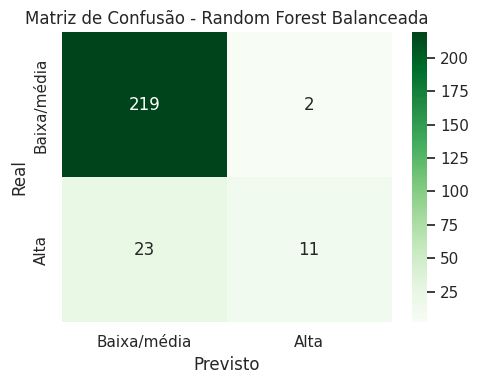

Relatório resumido - Random Forest balanceada


,modelo,balanceamento,acurácia,precisão,recall,f1_score,roc_auc
0,Random Forest,Com balanceamento,0.901961,0.846154,0.323529,0.468085,0.922811



Relatório por classe:
              precision    recall  f1-score   support

 Baixa/média       0.90      0.99      0.95       221
        Alta       0.85      0.32      0.47        34

    accuracy                           0.90       255
   macro avg       0.88      0.66      0.71       255
weighted avg       0.90      0.90      0.88       255



In [49]:
random_forest_balanced = RandomForestClassifier(
    n_estimators=150,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

random_forest_balanced.fit(X_train, y_train)

y_pred_rf_bal = random_forest_balanced.predict(X_test)
y_proba_rf_bal = random_forest_balanced.predict_proba(X_test)[:, 1]

metricas_rf_bal = {
    'modelo': 'Random Forest',
    'balanceamento': 'Com balanceamento',
    'acurácia': accuracy_score(y_test, y_pred_rf_bal),
    'precisão': precision_score(y_test, y_pred_rf_bal, zero_division=0),
    'recall': recall_score(y_test, y_pred_rf_bal, zero_division=0),
    'f1_score': f1_score(y_test, y_pred_rf_bal, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_rf_bal)
}
metricas_modelos.append(metricas_rf_bal)

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf_bal),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Baixa/média', 'Alta'],
    yticklabels=['Baixa/média', 'Alta']
)
plt.title('Matriz de Confusão - Random Forest Balanceada')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'matriz_confusao_random_forest_balanceada.png', dpi=120)
plt.show()

print('Relatório resumido - Random Forest balanceada')
display(pd.DataFrame([metricas_rf_bal]))

print('\nRelatório por classe:')
print(classification_report(y_test, y_pred_rf_bal, target_names=['Baixa/média', 'Alta'], zero_division=0))


### 6.3 Comparação Final dos Modelos

A tabela abaixo junta os resultados antes e depois do balanceamento. Para este problema, o F1-score e o recall da classe de alta qualidade são especialmente importantes, porque queremos encontrar os vinhos realmente bons, e não apenas acertar a maioria dos casos comuns.

O melhor modelo deve ser escolhido olhando a tabela final. Se a Regressão Logística aparecer melhor que o Random Forest em alguma execução, isso não é necessariamente erro: pode acontecer por causa da quantidade pequena de vinhos de alta qualidade e da divisão entre treino e teste.


,modelo,balanceamento,acurácia,precisão,recall,f1_score,roc_auc
2,Logistic Regression,Com balanceamento,0.815686,0.408451,0.852941,0.552381,0.895795
0,Logistic Regression,Sem balanceamento,0.890196,0.650000,0.382353,0.481481,0.899787
1,Random Forest,Sem balanceamento,0.898039,0.750000,0.352941,0.480000,0.909502
3,Random Forest,Com balanceamento,0.901961,0.846154,0.323529,0.468085,0.922811


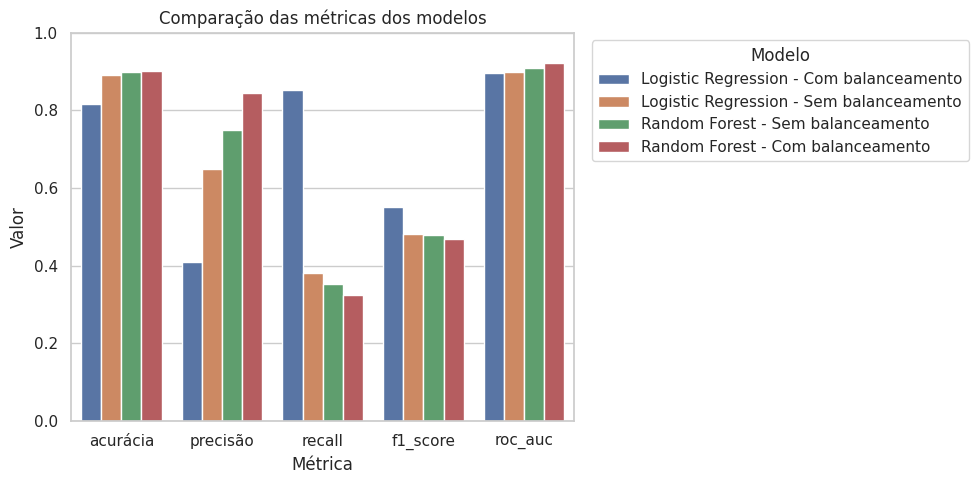

In [50]:
resultados_df = pd.DataFrame(metricas_modelos).sort_values(['f1_score', 'roc_auc'], ascending=False)
resultados_df.to_csv(RESULTS_PATH / 'metricas_modelos.csv', index=False)
display(resultados_df)

metricas_para_grafico = resultados_df.melt(
    id_vars=['modelo', 'balanceamento'],
    value_vars=['acurácia', 'precisão', 'recall', 'f1_score', 'roc_auc'],
    var_name='métrica',
    value_name='valor'
)
metricas_para_grafico['modelo_completo'] = metricas_para_grafico['modelo'] + ' - ' + metricas_para_grafico['balanceamento']

plt.figure(figsize=(10, 5))
sns.barplot(data=metricas_para_grafico, x='métrica', y='valor', hue='modelo_completo')
plt.title('Comparação das métricas dos modelos')
plt.xlabel('Métrica')
plt.ylabel('Valor')
plt.ylim(0, 1)
plt.legend(title='Modelo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'comparacao_metricas_modelos.png', dpi=120)
plt.show()


## 7. Fatores Mais Importantes para um Vinho ser de Alta Qualidade

Depois dos modelos, foi analisada a importância das variáveis usando o Random Forest balanceado. Mesmo que ele não seja o melhor modelo em todas as métricas, ele é útil para enxergar quais características mais pesaram nas decisões das árvores.


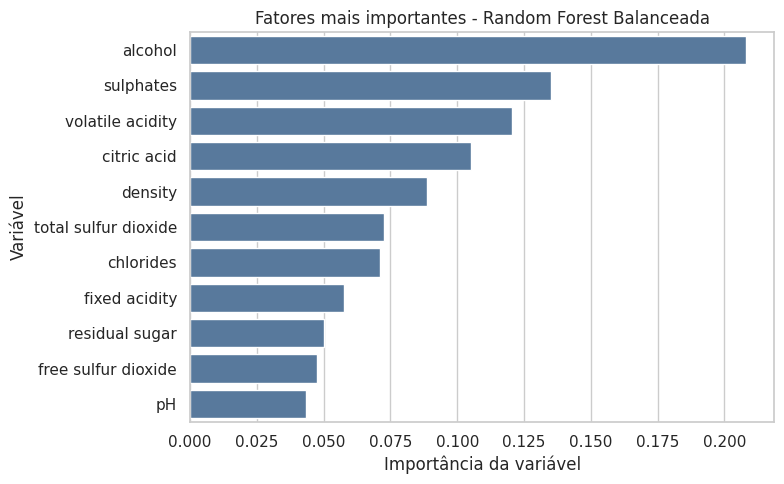

Principais fatores encontrados pelo modelo:


,variavel,importancia
10,alcohol,0.208186
9,sulphates,0.135081
1,volatile acidity,0.120439
2,citric acid,0.105141
7,density,0.088620
6,total sulfur dioxide,0.072457
4,chlorides,0.071193
0,fixed acidity,0.057792


In [51]:
importancias = pd.DataFrame({
    'variavel': features,
    'importancia': random_forest_balanced.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importancias,
    x='importancia',
    y='variavel',
    color='#4c78a8'
)

plt.title('Fatores mais importantes - Random Forest Balanceada')
plt.xlabel('Importância da variável')
plt.ylabel('Variável')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'importancia_variaveis.png', dpi=120)
plt.show()

print('Principais fatores encontrados pelo modelo:')
display(importancias.head(8))


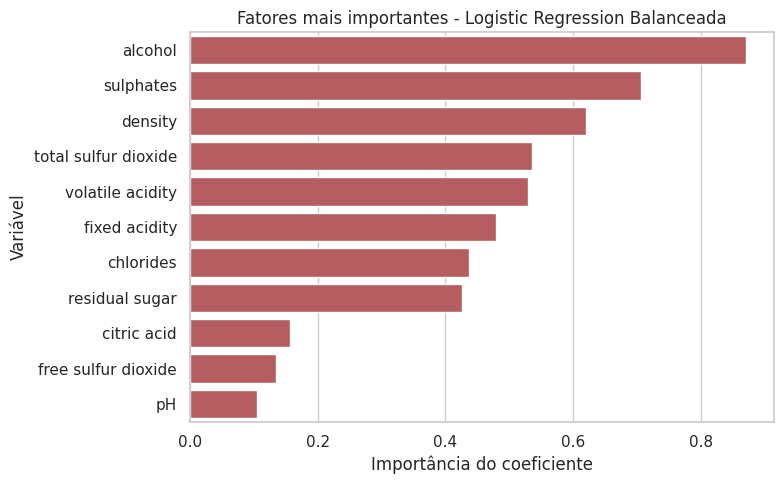

Principais fatores encontrados pela Regressão Logística:


,variavel,coeficiente,importancia
10,alcohol,0.871059,0.871059
9,sulphates,0.706011,0.706011
7,density,-0.620227,0.620227
6,total sulfur dioxide,-0.535003,0.535003
1,volatile acidity,-0.528826,0.528826
0,fixed acidity,0.478459,0.478459
4,chlorides,-0.436388,0.436388
3,residual sugar,0.425555,0.425555


In [52]:
coeficientes_lr = logistic_regression_balanced.named_steps['model'].coef_[0]

importancias_lr = pd.DataFrame({
    'variavel': features,
    'coeficiente': coeficientes_lr,
    'importancia': abs(coeficientes_lr)
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importancias_lr, x='importancia', y='variavel', color='#c44e52')
plt.title('Fatores mais importantes - Logistic Regression Balanceada')
plt.xlabel('Importância do coeficiente')
plt.ylabel('Variável')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'importancia_variaveis_logistic_regression.png', dpi=120)
plt.show()

print('Principais fatores encontrados pela Regressão Logística:')
display(importancias_lr.head(8))


Com base na análise, os fatores mais importantes ajudam a indicar o que mais diferencia os vinhos de alta qualidade. Em geral, variáveis como teor alcoólico, acidez volátil, sulfatos, densidade e acidez aparecem como pontos relevantes para acompanhar no processo produtivo.

Isso não significa que uma única variável define a qualidade do vinho sozinha. O resultado depende da combinação das características, mas esses fatores dão uma boa direção para entender o que está mais ligado aos vinhos considerados melhores.


## 8. Conclusão

A base analisada possui mais vinhos de baixa ou média qualidade do que vinhos de alta qualidade, então o balanceamento é um ponto importante da análise.

Foram testados dois modelos principais: Logistic Regression e Random Forest. Primeiro eles foram avaliados sem balanceamento e depois com `class_weight='balanced'`, sempre usando a mesma divisão de treino e teste: 75% para treino e 25% para teste.

A escolha do melhor modelo deve considerar a tabela de métricas, principalmente precisão, recall, F1-score e ROC-AUC. O Random Forest ajuda bastante na interpretação dos fatores importantes, mas a Regressão Logística pode ter resultado competitivo ou até melhor dependendo da divisão dos dados e do desbalanceamento das classes.


### 8.1 Visualização comparativa dos fatores mais influentes

Para facilitar a leitura no relatório final, foi criada uma visualização comparando os principais fatores apontados pelos dois modelos. Como a Regressão Logística e o Random Forest usam escalas diferentes, o gráfico abaixo usa um score relativo de 0 a 1 dentro de cada modelo apenas para comparação visual.


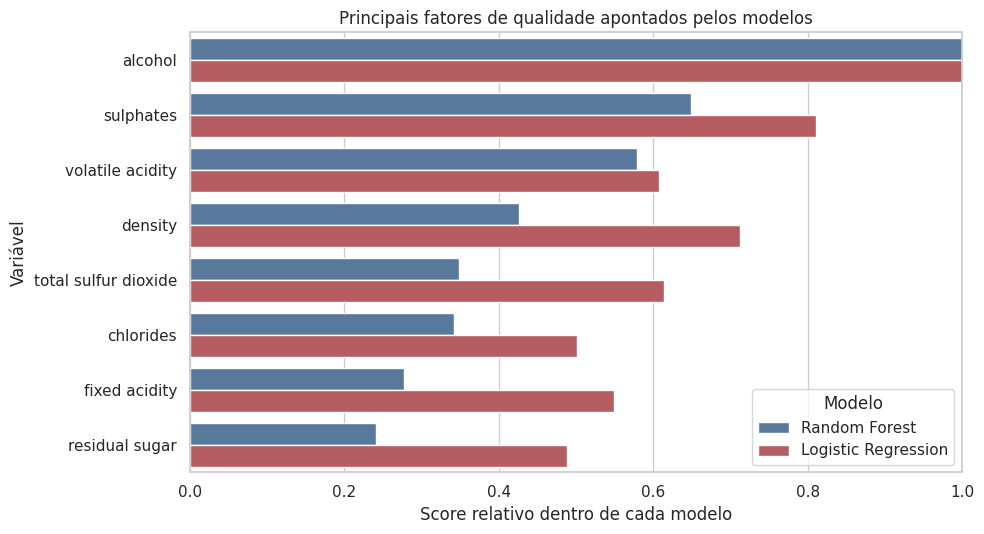

modelo,Logistic Regression,Random Forest
variavel,,
alcohol,1.000,1.000
sulphates,0.811,0.649
volatile acidity,0.607,0.579
density,0.712,0.426
total sulfur dioxide,0.614,0.348
chlorides,0.501,0.342
fixed acidity,0.549,0.278
residual sugar,0.489,0.241


In [53]:
# Comparação visual dos fatores mais influentes nos dois modelos
# Observação: o score abaixo é relativo dentro de cada modelo.
# Ele serve para comparar a ordem e a força relativa dos fatores, não os valores absolutos.

rf_fatores = importancias[['variavel', 'importancia']].copy()
rf_fatores['modelo'] = 'Random Forest'
rf_fatores['score_relativo'] = rf_fatores['importancia'] / rf_fatores['importancia'].max()

lr_fatores = importancias_lr[['variavel', 'importancia']].copy()
lr_fatores['modelo'] = 'Logistic Regression'
lr_fatores['score_relativo'] = lr_fatores['importancia'] / lr_fatores['importancia'].max()

fatores_comparativo = pd.concat([rf_fatores, lr_fatores], ignore_index=True)

# Seleciona as variáveis mais relevantes considerando os dois modelos juntos
top_variaveis = (
    fatores_comparativo
    .groupby('variavel')['score_relativo']
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

grafico_fatores = fatores_comparativo[fatores_comparativo['variavel'].isin(top_variaveis)].copy()
ordem_variaveis = (
    grafico_fatores
    .groupby('variavel')['score_relativo']
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 5.5))
sns.barplot(
    data=grafico_fatores,
    x='score_relativo',
    y='variavel',
    hue='modelo',
    order=ordem_variaveis,
    palette=['#4c78a8', '#c44e52']
)

plt.title('Principais fatores de qualidade apontados pelos modelos')
plt.xlabel('Score relativo dentro de cada modelo')
plt.ylabel('Variável')
plt.xlim(0, 1)
plt.legend(title='Modelo', loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'principais_fatores_comparativo.png', dpi=120)
plt.show()

display(
    grafico_fatores
    .pivot_table(index='variavel', columns='modelo', values='score_relativo')
    .loc[ordem_variaveis]
    .round(3)
)
